# Function 5 Analysis - Week 1

This notebook contains the exploratory analysis for **Function 5** in Week 1. We examine the initial datapoints to understand the relationship between inputs (x1, x2, x3, x4) and the output (y), then use an exploitation strategy around the best observed peak.

**Function Description:** 	
You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

## Loading and Displaying the Data

We load the initial inputs and outputs for function 5 and display them in a table format to inspect the raw data values. We note that the best outputs have on average high x values compared to the worst. There is one positive value that stands out: observation 15 with y = 1089. The second best value is observation 18 with only 432. This is a sharp drop. Since we know that the function is unimodal, exploitation dominates over exploration. We don't need to worry about missing a distant peak.


In [13]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_5")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")
df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,y
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525
5,0.683432,0.118663,0.829046,0.567577,78.434389
6,0.553621,0.667350,0.323806,0.814870,57.571537
7,0.352356,0.322242,0.116979,0.473113,109.571876
8,0.153786,0.729382,0.422598,0.443074,8.847992
9,0.463442,0.630025,0.107906,0.957644,233.223610


df sorted by y


,x1,x2,x3,x4,y,x_avg
0,0.224189,0.846480,0.879484,0.878516,1088.859618,0.707167
1,0.119879,0.862540,0.643331,0.849804,431.612757,0.618889
2,0.438933,0.774092,0.378167,0.933696,355.806818,0.631222
3,0.836478,0.193610,0.663893,0.785649,258.370525,0.619907
4,0.463442,0.630025,0.107906,0.957644,233.223610,0.539754
5,0.352356,0.322242,0.116979,0.473113,109.571876,0.316172
6,0.511142,0.817957,0.728710,0.112354,79.729130,0.542541
7,0.683432,0.118663,0.829046,0.567577,78.434389,0.549679
8,0.191447,0.038193,0.607418,0.414584,64.443440,0.312911
9,0.583973,0.147243,0.348097,0.428615,64.420147,0.376982


## Correlation Matrix

The correlation heatmap shows pairwise correlations between all variables (x1, x2, x3, x4, and y). This helps identify linear relationships. If correlations are weak, it suggests the function may be non-linear or have complex interactions between variables.


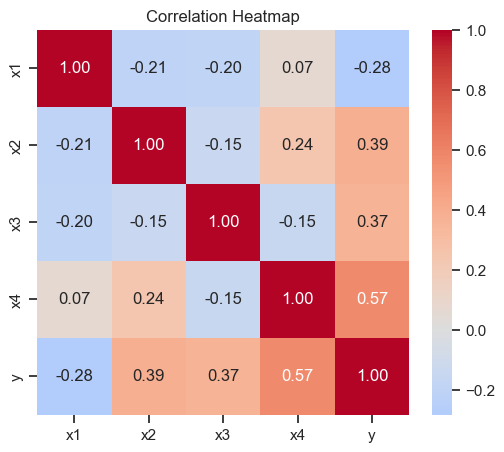

In [14]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## Pairplot Analysis

The pairplot provides a comprehensive view of pairwise relationships between all variables. The diagonal shows distributions (histograms), while off-diagonal plots show scatter plots. This helps identify patterns, clusters, and potential non-linear relationships that might not be captured by correlation alone.


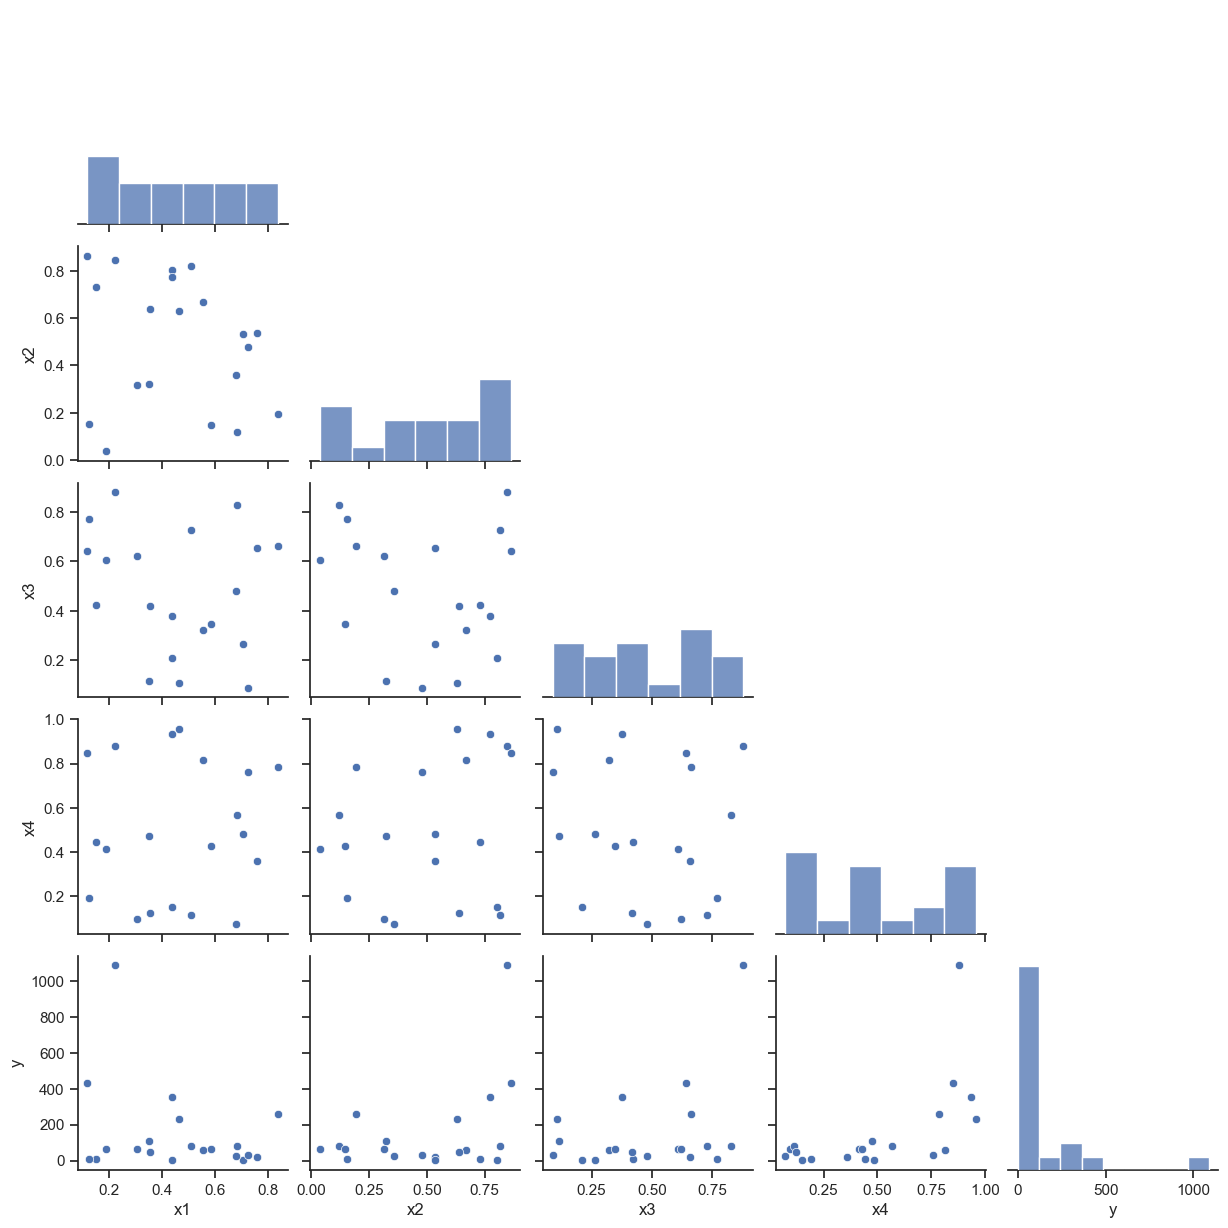

In [15]:
sns.pairplot(df, corner=True, diag_kind="hist")
plt.show()


## Analysis and recommendation

Since we know that the function has only one peak, we will run a strategy of exploitation around the best observed peak, by perturbing one variable at a time. This strategy requires us to get several more data points over the coming weeks before getting a good understanding of the local shape of the function. By systematically varying one variable while keeping others fixed, we can map out the local landscape around the peak and refine our understanding of the optimal region. We note that the current best value shows high values for x2-x4 and a low value for x1. x1 thus appears as a good starting point to see if increasing x1 increases y. Our recommended point is: x1 = 0.191447	x2 = 0.846480	x3 = 0.879484	x4 = 0.878516.